# Deutsch Algorithm

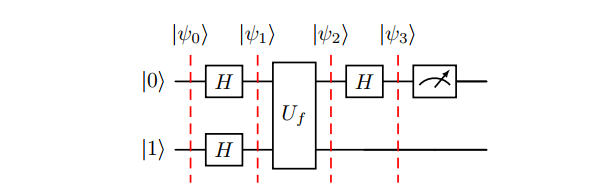

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualization Function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=False, initial_state = True)

In [17]:
qc = QuantumCircuit(2,1)

# Initialization
qc.x(1)
qc.barrier(label = '|01>')

# Apply Hadamard
qc.h(range(2))
qc.barrier(label = 'H^2')

# Apply Oracle f(0) = f(1) = 1 ---> Constant
qc.x(1)
qc.barrier(label = 'Oracle')
# Apply final Hadamard
qc.h(0)
qc.barrier()

# Measurement
qc.measure(0, 0)

#display(qplot(qc), Statevector(qc).draw('latex'))
qplot(qc)

|01> ┌───┐ H^2       Oracle ┌───┐ ░ ┌─┐
q_0: |0>───────░───┤ H ├──░──────────░────┤ H ├─░─┤M├
        ┌───┐  ░   ├───┤  ░  ┌───┐   ░    └───┘ ░ └╥┘
q_1: |0>┤ X ├──░───┤ H ├──░──┤ X ├───░──────────░──╫─
        └───┘  ░   └───┘  ░  └───┘   ░          ░  ║ 
   c: 0 ═══════════════════════════════════════════╩═

In [19]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc, shots = 100)
result = job.result()
counts = result.get_counts()
counts

{'0': 100}

In [20]:
qc = QuantumCircuit(2,1)

# Initialization
qc.x(1)
qc.barrier(label = '|01>')

# Apply Hadamard
qc.h(range(2))
qc.barrier(label = 'H^2')

# Apply Oracle f(0) =0, f(1) = 1 ---> Balanced
qc.cx(0,1)
qc.barrier(label = 'Oracle')
# Apply final Hadamard
qc.h(0)
qc.barrier()

# Measurement
qc.measure(0, 0)

#display(qplot(qc), Statevector(qc).draw('latex'))
qplot(qc)

|01> ┌───┐ H^2       Oracle ┌───┐ ░ ┌─┐
q_0: |0>───────░───┤ H ├──░────■─────░────┤ H ├─░─┤M├
        ┌───┐  ░   ├───┤  ░  ┌─┴─┐   ░    └───┘ ░ └╥┘
q_1: |0>┤ X ├──░───┤ H ├──░──┤ X ├───░──────────░──╫─
        └───┘  ░   └───┘  ░  └───┘   ░          ░  ║ 
   c: 0 ═══════════════════════════════════════════╩═

In [21]:
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc, shots = 100)
result = job.result()
counts = result.get_counts()
counts

{'1': 100}